## Procesamiento batch con Streamlit

### By: Carlos Javier Palacios Sanchez

### Date: 07/09/2026

### Description:

Requerimiento

- Crear una interfaz que reciba un archivo con múltiples registros y permita descargar
  o visualizar las predicciones generadas.
- Incluir archivos de ejemplo de entrada y salida.
- Incluir instrucciones de uso y evidencia de funcionamiento.

---

## Solución

| Entregable | Ruta |
|---|---|
| Interfaz | `src/demo/pages/Procesamiento_por_lotes.py` |
| Lógica del lote | `src/demo/lote.py` |
| Pruebas | `tests/demo/test_lote.py` |
| Ejemplo de entrada | `notebooks/16.../ejemplos/entrada_ejemplo.csv` |
| Ejemplo de salida | `notebooks/16.../ejemplos/salida_ejemplo.csv` |
| Ejemplo inválido | `notebooks/16.../ejemplos/entrada_invalida_ejemplo.csv` |
| Instrucciones | `src/demo/README.md`, sección *Uso del procesamiento por lotes* |
| Evidencia | `notebooks/16.../evidencia/*.png` |

### Por qué una página de la demo y no una app aparte

La demo del entregable 15 ya carga el modelo, ya conoce el umbral calibrado y ya sabe
buscar el artefacto en `models/`. Montar una segunda aplicación para los lotes
significaría duplicar las tres cosas y tener dos despliegues que mantener sincronizados.

Streamlit resuelve esto con el mecanismo de páginas: cualquier archivo dentro de
`src/demo/pages/` aparece como una entrada en la barra lateral de la app principal. El
lote es entonces **una página más del mismo despliegue**, con la misma URL, el mismo
modelo cargado y el mismo control de umbral. Y sigue pudiendo arrancarse sola cuando
sólo interesa el lote:

```bash
uv run streamlit run src/demo/pages/Procesamiento_por_lotes.py
```

### Por qué la lógica no vive en la página

La página de Streamlit son **sólo widgets**. Leer el archivo, validarlo, predecir y
resumir está en `src/demo/lote.py`, un módulo que no importa `streamlit`.

El motivo es que una función dentro de un script de Streamlit no se puede probar con
pytest sin levantar un navegador. Si la validación de columnas viviera junto al
`st.file_uploader`, la única forma de comprobar que un archivo al que le falta `thal`
produce un error claro sería mirarlo con los ojos. Separándolo, las 21 pruebas del
entregable cubren el comportamiento real del lote y en la página no queda ninguna
decisión que merezca una prueba.

## 📚 Import libraries

In [18]:
"""Notebook de evidencia del entregable 16.

Se importa la lógica del lote tal cual la usa la página de Streamlit: este notebook no
reimplementa nada, sólo ejerce el módulo y enseña lo que sale.
"""

import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd()
while not (RAIZ / "src").is_dir() and RAIZ.parent != RAIZ:
    RAIZ = RAIZ.parent

if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

from demo import lote  # noqa: E402
from pipelines.inference_pipeline.inference_pipeline import cargar_modelo  # noqa: E402

AQUI = RAIZ / "notebooks" / "16.Procesamiento batch con Streamlit"
EJEMPLOS = AQUI / "ejemplos"
EVIDENCIA = AQUI / "evidencia"

print(f"Raíz del proyecto: {RAIZ}")
print(f"Formatos aceptados: {lote.EXTENSIONES_ACEPTADAS}")
print(f"Máximo de filas por archivo: {lote.MAX_FILAS:,}")

Raíz del proyecto: /mnt/c/Users/KATANA/Heart_project
Formatos aceptados: ['csv', 'xlsx', 'parquet']
Máximo de filas por archivo: 5,000


## 1. El archivo de entrada

`entrada_ejemplo.csv` son 40 pacientes tomados del conjunto original, sin la variable
objetivo. Trae a propósito tres cosas que un archivo real tiene y una plantilla de
juguete no:

- una columna identificadora (`id_paciente`) para poder casar cada predicción con su
  paciente,
- una columna que el modelo no usa (`centro`), para comprobar que sobrevive a la
  salida,
- **tres celdas vacías** en `chol`, `old_peak` y `rest_bp`.

In [19]:
entrada = pd.read_csv(EJEMPLOS / "entrada_ejemplo.csv", dtype=str)

print(f"{len(entrada)} filas x {entrada.shape[1]} columnas")
print(f"Celdas vacías: {int(entrada.isna().sum().sum())}")
entrada.head(8)

40 filas x 15 columnas
Celdas vacías: 3


,id_paciente,centro,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal
0,P-001,Clínica Norte,47,Male,asymptomatic,112,204,0,normal,143,0,0.1,1,0.0,normal
1,P-002,Clínica Sur,41,Male,asymptomatic,110,172,0,left ventricular hypertrophy,158,0,0.0,1,0.0,reversable
2,P-003,Clínica Norte,59,Male,nonanginal,126,218,1,normal,134,0,2.2,2,1.0,fixed
3,P-004,Clínica Sur,60,Male,nonanginal,140,NaN,0,left ventricular hypertrophy,155,0,3.0,2,0.0,normal
4,P-005,Clínica Norte,41,Male,nontypical,135,203,0,normal,132,0,0.0,2,0.0,fixed
5,P-006,Clínica Sur,60,Female,asymptomatic,158,305,0,left ventricular hypertrophy,161,0,0.0,1,0.0,normal
6,P-007,Clínica Norte,38,Male,typical,120,231,0,normal,182,1,3.8,2,0.0,reversable
7,P-008,Clínica Sur,67,Female,asymptomatic,106,223,0,normal,142,0,0.3,1,2.0,normal


## 2. Lectura y validación

`leer_archivo` hace lo mismo que `leer_datos_nuevos` del inference pipeline: lee **todo
como texto**. Si pandas infiriera tipos, un valor corrupto en una columna numérica
convertiría la columna entera en texto sin avisar, y el saneamiento se encontraría un
problema distinto del que hay. Quien decide qué es interpretable es el feature pipeline.

`validar_columnas` comprueba que estén las 13 obligatorias y devuelve las que sobran,
para poder avisar de que no entran al modelo.

In [20]:
crudo = lote.leer_archivo("entrada_ejemplo.csv", (EJEMPLOS / "entrada_ejemplo.csv").read_bytes())
ignoradas = lote.validar_columnas(crudo)

print(f"Filas leídas: {len(crudo)}")
print(f"Columnas obligatorias presentes: {len(lote.COLS_REQUERIDAS)}/13")
print(f"Columnas que el modelo no usa (se conservan en la salida): {ignoradas}")

Filas leídas: 40
Columnas obligatorias presentes: 13/13
Columnas que el modelo no usa (se conservan en la salida): ['id_paciente', 'centro']


### Qué pasa cuando el archivo no sirve

`entrada_invalida_ejemplo.csv` es el mismo archivo sin `ca` ni `thal`. La regla del
entregable 14 se mantiene: **si los datos no encajan con lo que el modelo espera, no se
predice nada**. No se imputa la columna ausente ni se devuelve un lote parcial; un CSV a
medias es peor que ninguno porque parece completo.

In [21]:
ruta_invalida = EJEMPLOS / "entrada_invalida_ejemplo.csv"

try:
    datos = lote.leer_archivo(ruta_invalida.name, ruta_invalida.read_bytes())
    lote.validar_columnas(datos)
except lote.ErrorDeLote as error:
    print(f"{type(error).__name__}:\n\n{error}")

ErrorDeLote:

Al archivo le faltan 2 columnas obligatorias: ca, thal.

El archivo debe traer estas 13: age, sex, chest_pain, rest_bp, chol, fbs, rest_ecg, max_hr, exang, old_peak, slope, ca, thal.


## 3. Predicción del lote

`predecir_lote` no transforma nada por su cuenta: llama a `transformar` y
`alinear_columnas` del `inference_pipeline`, que a su vez importa el `feature_pipeline`.
Es la misma ruta de transformación del entrenamiento, de la inferencia por archivo y de
la demo individual.

Dos garantías que vienen de ahí:

1. **Ninguna fila se pierde.** `transformar` falla si el número de filas cambia, así que
   40 pacientes devuelven 40 predicciones o ninguna. Perder una fila en silencio sería
   devolver el resultado de un paciente a otro.
2. **Los valores ausentes no tumban el lote.** Los imputa el `SimpleImputer` que viaja
   dentro del `Pipeline` serializado, con la mediana aprendida en el entrenamiento.

In [22]:
modelo = cargar_modelo(RAIZ / "models" / "modelo_corazon_completo.joblib")
predicciones = lote.predecir_lote(modelo, crudo, umbral=modelo.umbral)

print(f"Modelo: {modelo.metadatos.get('modelo')}  |  umbral calibrado: {modelo.umbral:.2f}")
print(f"Entran {len(crudo)} pacientes, salen {len(predicciones)} predicciones")
print(f"Columnas de la salida: {predicciones.shape[1]}")

predicciones[[lote.COL_ID, "centro", "age", "sex", *lote.COLS_PREDICCION]].head(10)

Modelo: gradient_boosting  |  umbral calibrado: 0.31
Entran 40 pacientes, salen 40 predicciones
Columnas de la salida: 19


,id_paciente,centro,age,sex,probabilidad_enfermedad,prediccion,diagnostico,nivel_riesgo
0,P-001,Clínica Norte,47,Male,0.1616,0,sano,muy bajo
1,P-002,Clínica Sur,41,Male,0.5546,1,enfermo,medio
2,P-003,Clínica Norte,59,Male,0.8994,1,enfermo,muy alto
3,P-004,Clínica Sur,60,Male,0.7859,1,enfermo,alto
4,P-005,Clínica Norte,41,Male,0.2116,0,sano,bajo
5,P-006,Clínica Sur,60,Female,0.5400,1,enfermo,medio
6,P-007,Clínica Norte,38,Male,0.8737,1,enfermo,muy alto
7,P-008,Clínica Sur,67,Female,0.2733,0,sano,bajo
8,P-009,Clínica Norte,57,Male,0.9684,1,enfermo,muy alto
9,P-010,Clínica Sur,56,Female,0.9652,1,enfermo,muy alto


### Las filas con huecos siguen ahí

Las tres celdas vacías del archivo de entrada están en los pacientes P-004, P-012 y
P-028. Salen con su probabilidad como cualquier otro.

In [23]:
con_huecos = predicciones[predicciones[["chol", "old_peak", "rest_bp"]].isna().any(axis=1)]
con_huecos[[lote.COL_ID, "chol", "old_peak", "rest_bp", *lote.COLS_PREDICCION]]

,id_paciente,chol,old_peak,rest_bp,probabilidad_enfermedad,prediccion,diagnostico,nivel_riesgo
3,P-004,NaN,3.0,140,0.7859,1,enfermo,alto
11,P-012,178,NaN,120,0.0584,0,sano,muy bajo
27,P-028,265,0.0,NaN,0.0675,0,sano,muy bajo


## 4. Resumen del lote

`resumen_lote` produce las cifras que la interfaz muestra en tarjetas. No es un cálculo
aparte: sale de la misma tabla que se descarga, y hay una prueba que comprueba que
cuadran.

In [24]:
resumen = lote.resumen_lote(predicciones, modelo.umbral)

for clave, valor in resumen.items():
    print(f"{clave:24s} {valor}")

filas                    40
umbral                   0.31
casos_probables          23
casos_descartados        17
proporcion_positivos     0.575
probabilidad_media       0.5076
probabilidad_maxima      0.9903
por_banda_de_riesgo      {'muy bajo': 15, 'bajo': 4, 'medio': 4, 'alto': 1, 'muy alto': 16}


### El umbral reclasifica, no vuelve a predecir

El umbral no forma parte del modelo: es la política de decisión. Moverlo en la interfaz
no vuelve a calcular nada, sólo cambia dónde se corta la probabilidad, y por eso el
usuario puede explorar el efecto sin volver a subir el archivo.

En un tamizaje cardíaco esto es la conversación importante: cuántos pacientes entran a
revisión según lo conservadora que sea la política.

In [25]:
comparacion = []
for umbral in (0.20, 0.31, 0.50, 0.70):
    lote_umbral = lote.predecir_lote(modelo, crudo, umbral=umbral)
    resumen_umbral = lote.resumen_lote(lote_umbral, umbral)
    comparacion.append(
        {
            "umbral": umbral,
            "casos_probables": resumen_umbral["casos_probables"],
            "descartados": resumen_umbral["casos_descartados"],
            "proporcion": resumen_umbral["proporcion_positivos"],
            "probabilidad_media": resumen_umbral["probabilidad_media"],
        }
    )

pd.DataFrame(comparacion)

,umbral,casos_probables,descartados,proporcion,probabilidad_media
0,0.20,25,15,0.625,0.5076
1,0.31,23,17,0.575,0.5076
2,0.50,20,20,0.500,0.5076
3,0.70,17,23,0.425,0.5076


La columna `probabilidad_media` es idéntica en las cuatro filas: la evidencia de que
mover el umbral no vuelve a predecir. Lo único que cambia es el corte.

## 5. El archivo de salida

`salida_ejemplo.csv` es exactamente lo que descarga el botón de la interfaz: el archivo
original **completo**, tal cual llegó, más las cuatro columnas de predicción. Se
adjuntan los datos de entrada para que el CSV sea auditable por sí solo: quien lo reciba
ve a qué paciente corresponde cada probabilidad sin cruzarlo con otro archivo.

Va en UTF-8 con BOM. Sin él, Excel en Windows lo abre en la codificación del sistema y
las tildes de `nivel_riesgo` salen rotas — y el destinatario típico de este archivo lo
abre en Excel.

In [26]:
salida = pd.read_csv(EJEMPLOS / "salida_ejemplo.csv")

print(f"{len(salida)} filas x {salida.shape[1]} columnas")
print(f"Columnas: {list(salida.columns)}")
salida.head(10)

40 filas x 19 columnas
Columnas: ['id_paciente', 'centro', 'age', 'sex', 'chest_pain', 'rest_bp', 'chol', 'fbs', 'rest_ecg', 'max_hr', 'exang', 'old_peak', 'slope', 'ca', 'thal', 'probabilidad_enfermedad', 'prediccion', 'diagnostico', 'nivel_riesgo']


,id_paciente,centro,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,probabilidad_enfermedad,prediccion,diagnostico,nivel_riesgo
0,P-001,Clínica Norte,47,Male,asymptomatic,112.0,204,0,normal,143,0,0.1,1,0.0,normal,0.1616,0,sano,muy bajo
1,P-002,Clínica Sur,41,Male,asymptomatic,110.0,172,0,left ventricular hypertrophy,158,0,0.0,1,0.0,reversable,0.5546,1,enfermo,medio
2,P-003,Clínica Norte,59,Male,nonanginal,126.0,218,1,normal,134,0,2.2,2,1.0,fixed,0.8994,1,enfermo,muy alto
3,P-004,Clínica Sur,60,Male,nonanginal,140.0,NaN,0,left ventricular hypertrophy,155,0,3.0,2,0.0,normal,0.7859,1,enfermo,alto
4,P-005,Clínica Norte,41,Male,nontypical,135.0,203,0,normal,132,0,0.0,2,0.0,fixed,0.2116,0,sano,bajo
5,P-006,Clínica Sur,60,Female,asymptomatic,158.0,305,0,left ventricular hypertrophy,161,0,0.0,1,0.0,normal,0.5400,1,enfermo,medio
6,P-007,Clínica Norte,38,Male,typical,120.0,231,0,normal,182,1,3.8,2,0.0,reversable,0.8737,1,enfermo,muy alto
7,P-008,Clínica Sur,67,Female,asymptomatic,106.0,223,0,normal,142,0,0.3,1,2.0,normal,0.2733,0,sano,bajo
8,P-009,Clínica Norte,57,Male,asymptomatic,150.0,276,0,left ventricular hypertrophy,112,1,0.6,2,1.0,fixed,0.9684,1,enfermo,muy alto
9,P-010,Clínica Sur,56,Female,asymptomatic,134.0,409,0,left ventricular hypertrophy,150,1,1.9,2,2.0,reversable,0.9652,1,enfermo,muy alto


### Comprobación: lo que se descarga es lo que se calculó

In [27]:
regenerado = pd.read_csv(pd.io.common.BytesIO(lote.a_csv(predicciones)))

iguales = regenerado["probabilidad_enfermedad"].equals(salida["probabilidad_enfermedad"])
print(f"El CSV del repositorio coincide con el que genera la interfaz: {iguales}")
print(f"Filas: {len(regenerado)} = {len(salida)}")

El CSV del repositorio coincide con el que genera la interfaz: True
Filas: 40 = 40


## 6. Instrucciones de uso

Las instrucciones completas están en `src/demo/README.md`, sección *Uso del
procesamiento por lotes*. En resumen:

**1. Abrir la página.** En el despliegue, *Procesamiento por lotes* en la barra lateral
de la demo. En local:

```bash
uv pip install -r requirements.txt
uv run streamlit run src/demo/app.py
```

**2. Preparar el archivo.** Una fila por paciente y, como mínimo, estas 13 columnas:

```
age, sex, chest_pain, rest_bp, chol, fbs, rest_ecg, max_hr, exang, old_peak, slope, ca, thal
```

Formatos: `.csv`, `.xlsx` y `.parquet`, hasta 5 000 filas. La propia página ofrece una
plantilla descargable con las columnas y una fila de ejemplo. Para volúmenes mayores
está el `inference_pipeline` por línea de comandos, que no tiene ese tope.

**3. Subirlo** en *Archivo de pacientes*.

**4. Leer el resultado.** Resumen con casos probables, proporción, probabilidad media,
reparto por banda de riesgo e histograma de probabilidades; y la tabla completa, con
filtro por banda —el filtro sólo afecta a lo que se ve—.

**5. Descargar el CSV** con el botón *Descargar predicciones*. Incluye siempre el lote
completo, independientemente del filtro.

**Ajustar el umbral** en la barra lateral reclasifica el lote ya predicho, sin volver a
subirlo.

## 7. Evidencia de funcionamiento

Capturas de la aplicación en ejecución, procesando `entrada_ejemplo.csv` de verdad.

### 7.1 La interfaz y el formato esperado

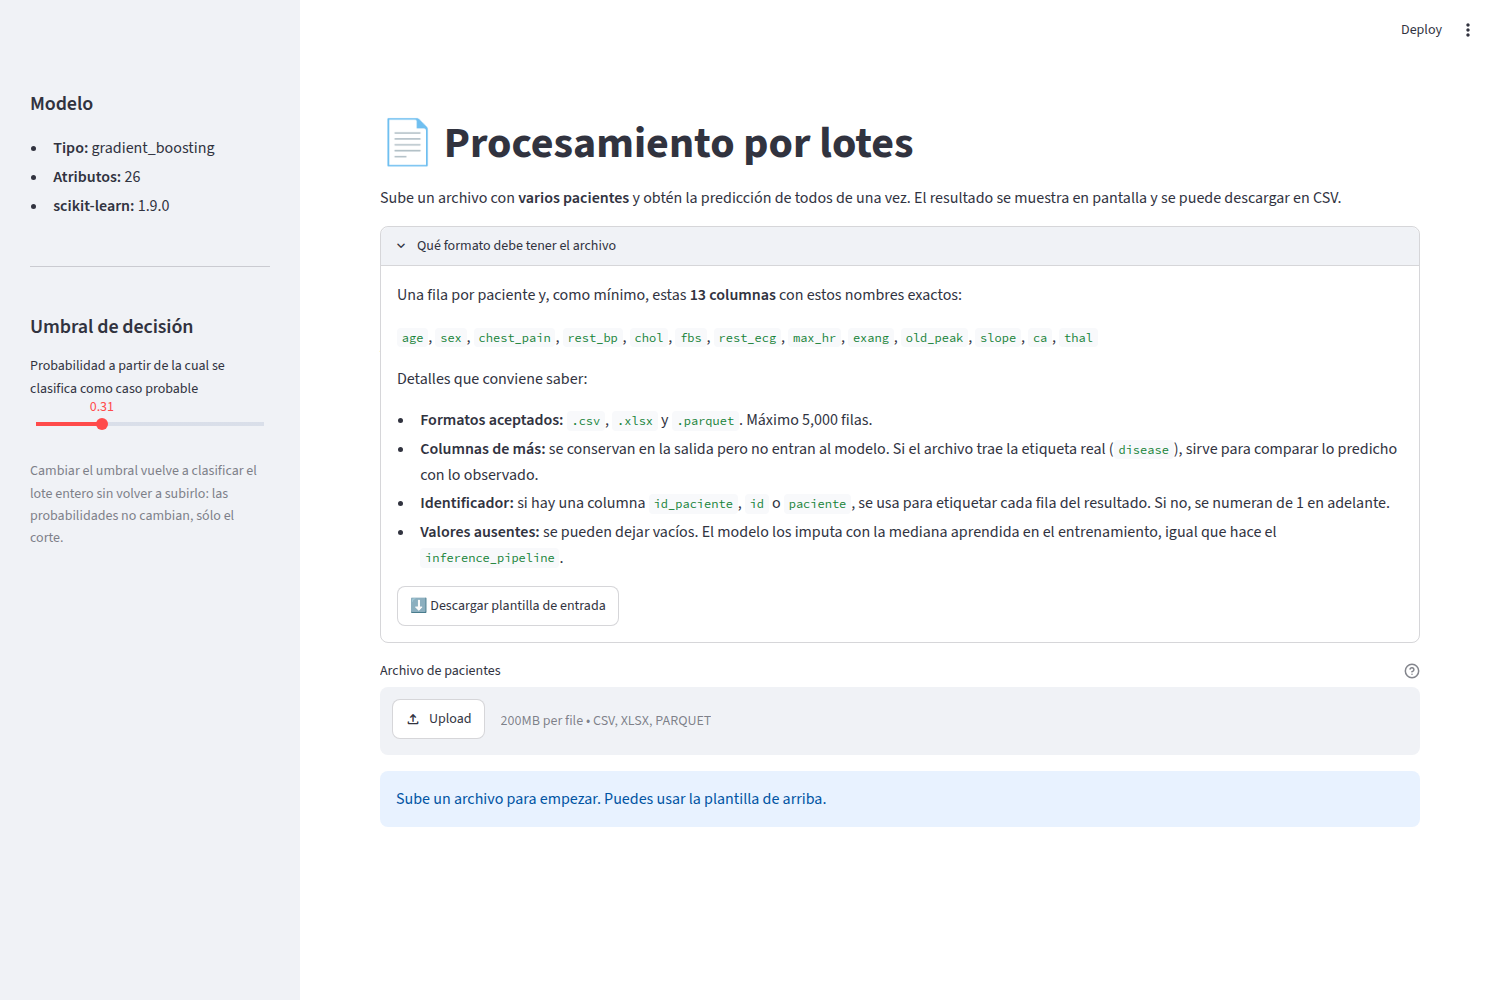

In [28]:
display(Image(filename=str(EVIDENCIA / "01_interfaz_y_formato.png")))

El panel desplegable enumera las 13 columnas obligatorias y las reglas del archivo, y
ofrece la plantilla descargable. La barra lateral muestra con qué modelo se está
prediciendo y el umbral aplicado.

### 7.2 Lote procesado: resumen y distribución

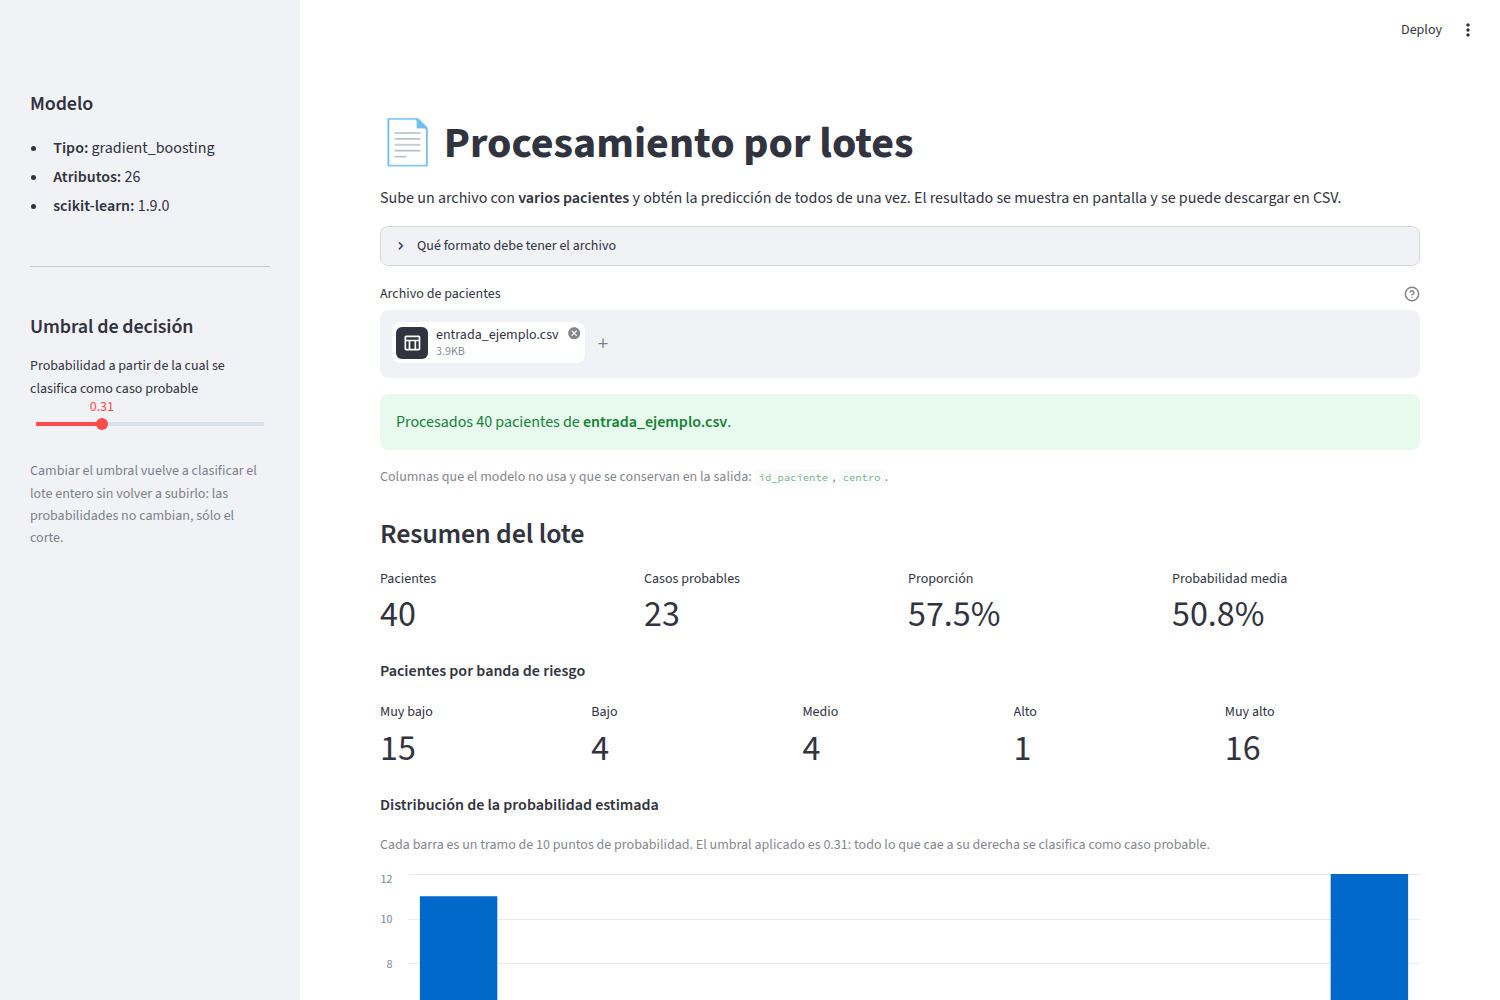

In [29]:
display(Image(filename=str(EVIDENCIA / "02_lote_procesado.png")))

40 pacientes, 23 casos probables con el umbral calibrado (0.31), probabilidad media
50.8 %. Debajo, el reparto por banda de riesgo —en orden, de *muy bajo* a *muy alto*— y
el histograma de probabilidades.

El reparto por banda va como tarjetas y no como gráfico de barras a propósito: un
gráfico ordenaría las categorías alfabéticamente —*alto* antes que *bajo*— y la lectura
de un vistazo dejaría de funcionar.

### 7.3 Tabla de predicciones y descarga

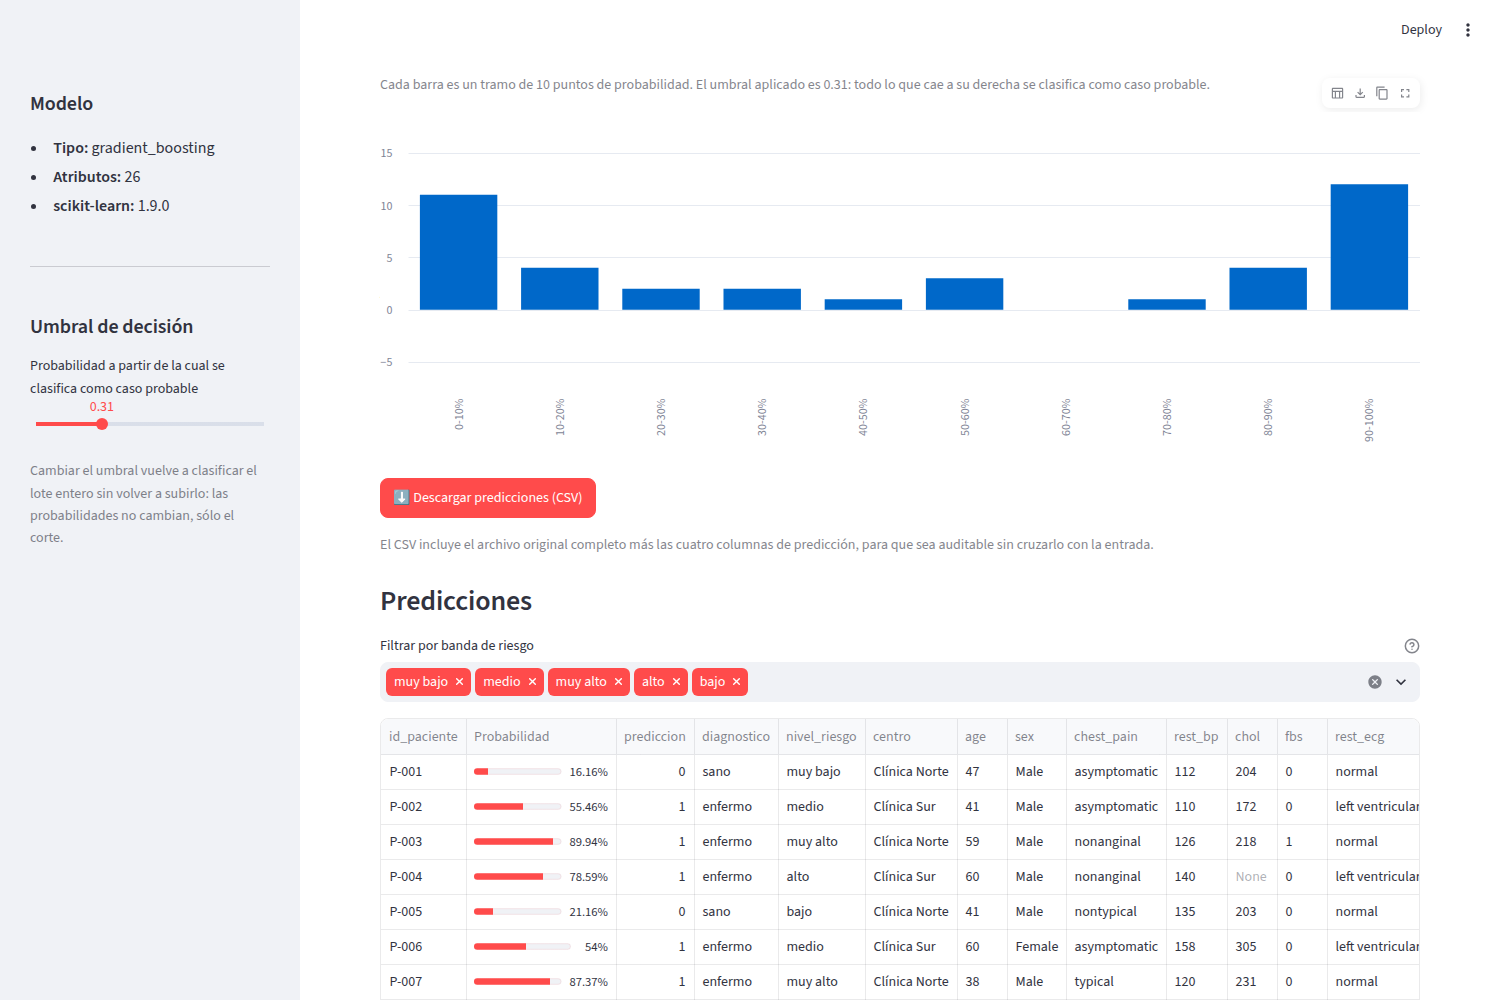

In [30]:
display(Image(filename=str(EVIDENCIA / "03_tabla_y_descarga.png")))

La tabla trae el identificador, la probabilidad como barra, la decisión, el diagnóstico
y la banda, seguidos del archivo original completo. El paciente P-004 aparece con `chol`
vacío y su predicción calculada, que es la evidencia de que el imputado funciona.

El histograma muestra la forma típica de este modelo: la mayoría de los pacientes cae en
los extremos, con pocos casos en la zona intermedia.

### 7.4 El umbral reclasifica el lote ya subido

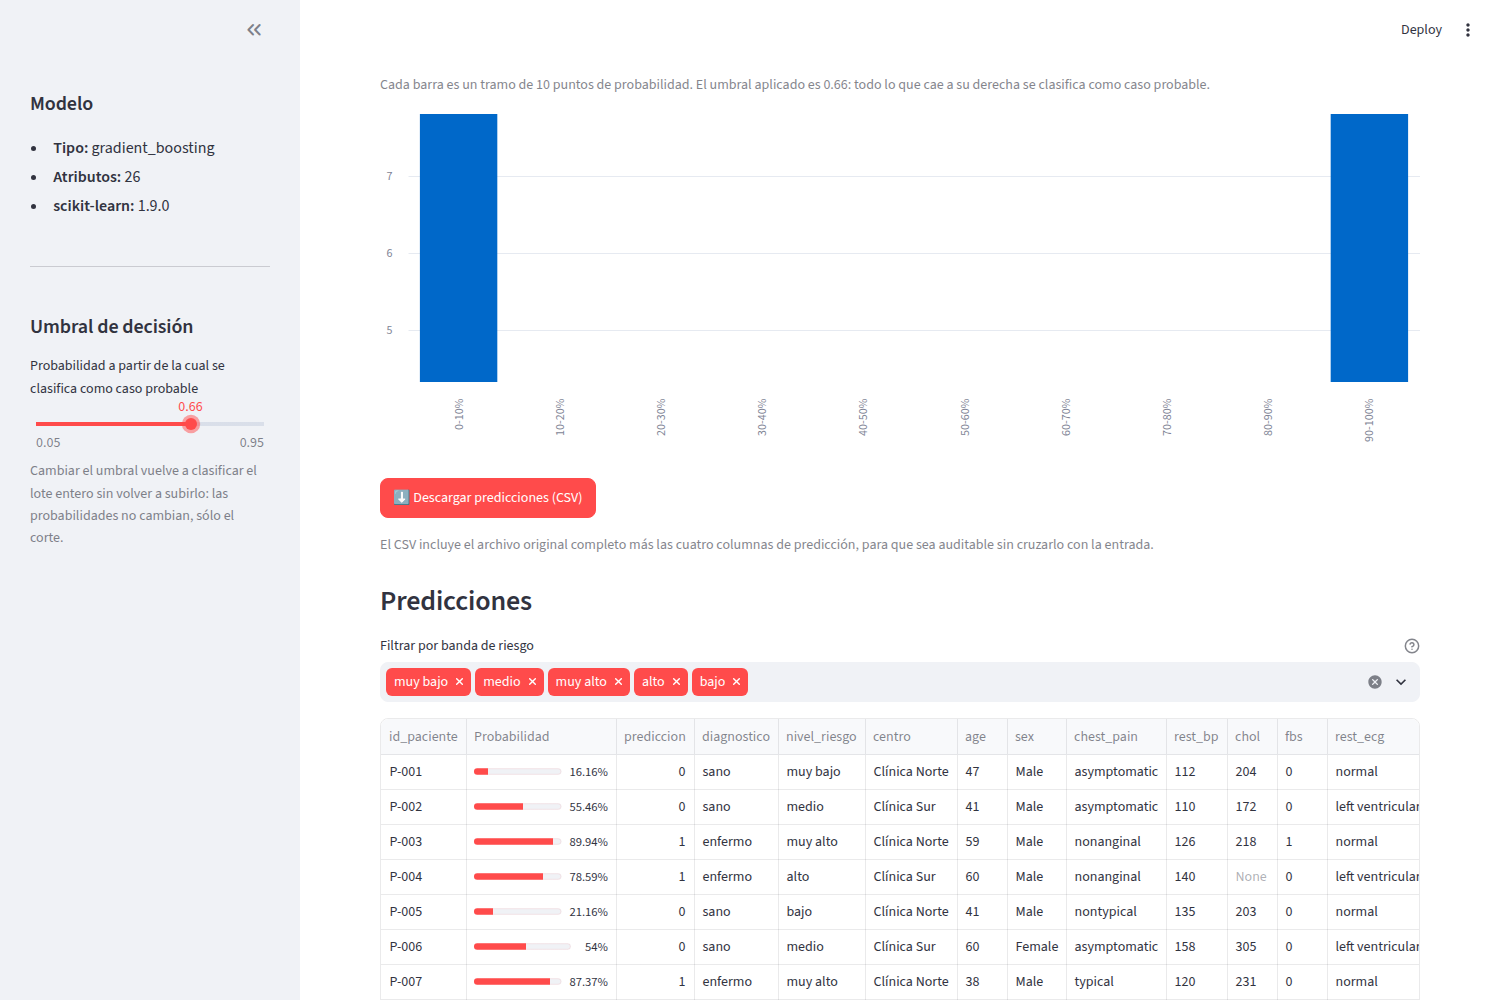

In [31]:
display(Image(filename=str(EVIDENCIA / "04_umbral_reclasifica.png")))

Mismo archivo, umbral movido de 0.31 a 0.66: los casos probables bajan de 23 a 17 y la
proporción de 57.5 % a 42.5 %, mientras la **probabilidad media se queda en 50.8 %**. No
se ha vuelto a predecir; sólo se ha movido el corte.

### 7.5 Archivo inválido: error claro y ninguna descarga

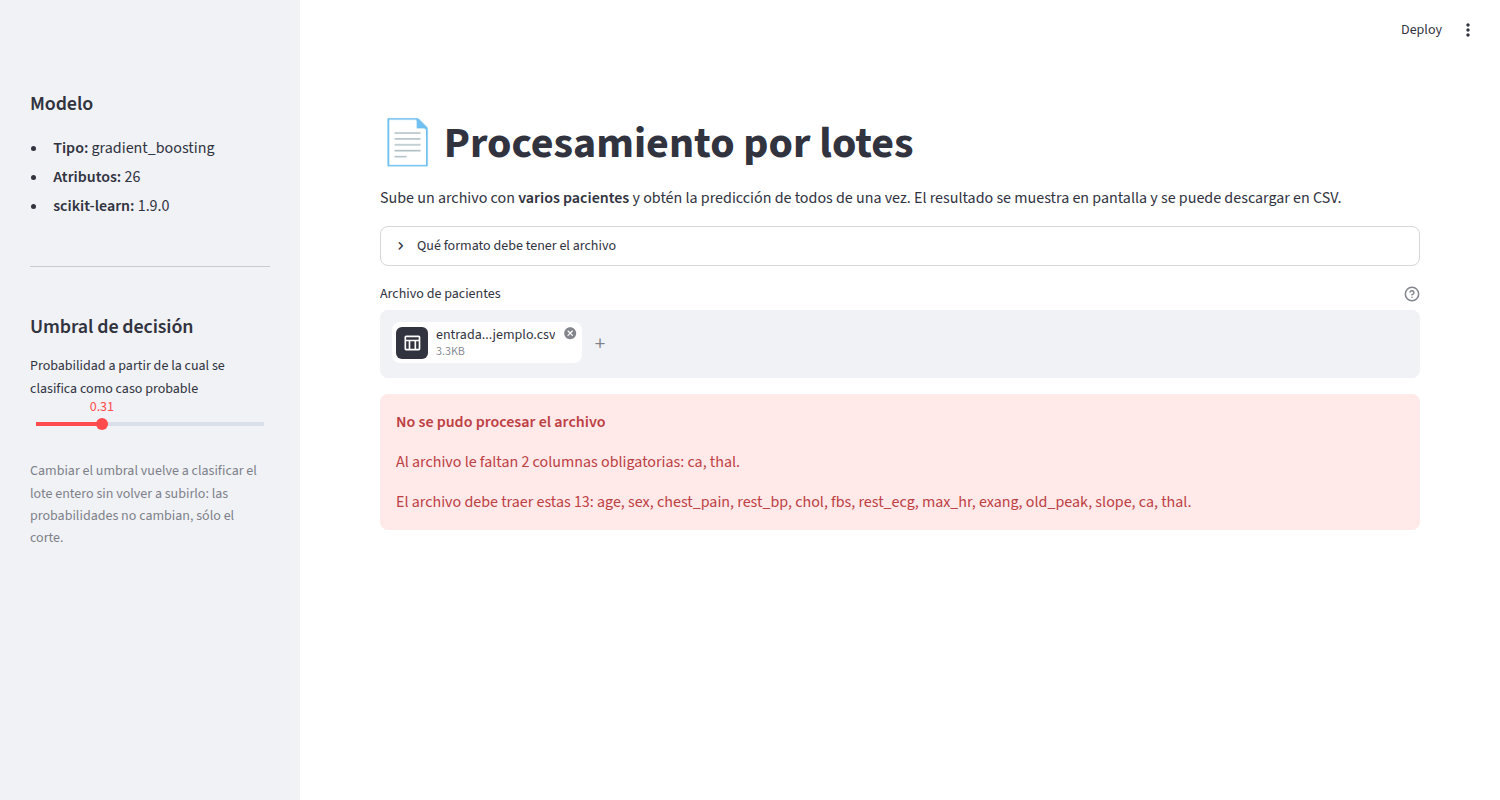

In [32]:
display(Image(filename=str(EVIDENCIA / "05_error_columnas_faltantes.png")))

Con `entrada_invalida_ejemplo.csv` la página dice qué columnas faltan y cuáles hacen
falta, y no aparece ni la tabla ni el botón de descarga.

### 7.6 La página dentro de la demo

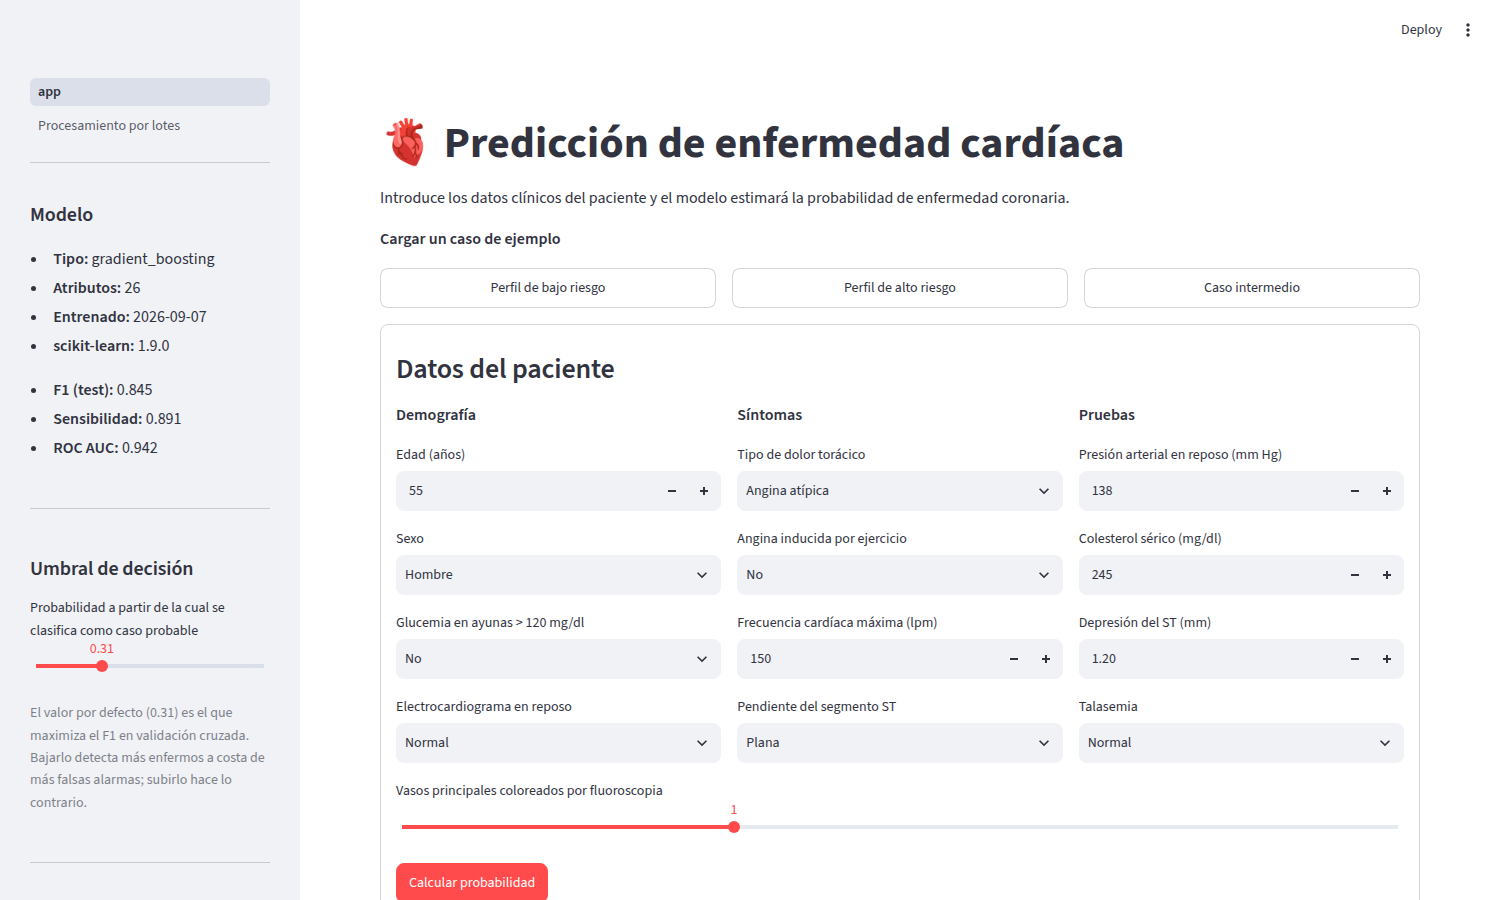

In [33]:
display(Image(filename=str(EVIDENCIA / "06_navegacion_en_la_demo.png")))

*Procesamiento por lotes* aparece en la barra lateral junto a la predicción individual:
un solo despliegue, un solo modelo cargado, dos formas de usarlo.

## 8. Pruebas

21 pruebas, todas con **modelo dummy y datos sintéticos**: la suite no depende de que
exista un modelo entrenado en el repositorio ni de que haya pacientes en `data/`.

In [34]:
pruebas = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/demo/test_lote.py", "-v", "--no-header", "-q"],
    cwd=RAIZ,
    capture_output=True,
    text=True,
    check=False,
)

print(pruebas.stdout[-4500:])
print(f"Código de salida: {pruebas.returncode}")

============================= test session starts ==============================
collected 22 items

tests/demo/test_lote.py ......................                           [100%]

=============================== warnings summary ===============================
tests/demo/test_lote.py::test_predecir_lote_devuelve_una_fila_por_paciente
tests/demo/test_lote.py::test_predecir_lote_devuelve_una_fila_por_paciente
tests/demo/test_lote.py::test_predecir_lote_devuelve_una_fila_por_paciente
tests/demo/test_lote.py::test_predecir_lote_devuelve_una_fila_por_paciente
tests/demo/test_lote.py::test_predecir_lote_devuelve_una_fila_por_paciente
tests/demo/test_lote.py::test_predecir_lote_devuelve_una_fila_por_paciente
  /mnt/c/Users/KATANA/Heart_project/.venv/lib/python3.12/site-packages/joblib/numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
  As an alternative, you can create a new view using np.reshape (with copy=False if needed).
    ar

Lo que cubren, por grupos:

| Grupo | Qué asegura |
|---|---|
| Lectura | CSV, Excel y Parquet se leen igual; todo entra como texto; un `.json`, un archivo vacío o uno por encima del tope se rechazan con un mensaje que dice qué hacer |
| Validación | falta una columna obligatoria → error; las columnas de más se reportan |
| Identificadores | se usa la columna del archivo, y si no hay se numeran las filas |
| Predicción | una fila por paciente; el archivo original sobrevive a la salida; los huecos se imputan; si falta una columna no sale ninguna predicción |
| Coherencia | **el lote da exactamente lo mismo que la demo individual**, paciente a paciente |
| Umbral | cambiarlo mueve la decisión pero no las probabilidades |
| Salida | el CSV descargado se puede volver a leer; el resumen cuadra con la tabla; la plantilla que ofrece la interfaz pasa su propia validación |

Las dos que más valen son las dos últimas categorías. La de coherencia falla si alguien
mete un atajo de transformación en el lote —normalizar por bloque, reordenar,
deduplicar—, que es exactamente la forma en que aparece el *training-serving skew*. Y la
de la plantilla evita una trampa fácil: publicar una plantilla que al subirla dé error.

## 📊 Analysis of Results and Conclusions

| Requisito | Dónde se cumple |
|---|---|
| Interfaz que recibe un archivo con múltiples registros | `st.file_uploader` en `pages/Procesamiento_por_lotes.py`; CSV, Excel y Parquet |
| Visualizar las predicciones generadas | resumen en tarjetas, reparto por banda, histograma y tabla filtrable |
| Descargar las predicciones generadas | botón *Descargar predicciones (CSV)*, lote completo |
| Archivos de ejemplo de entrada y salida | `ejemplos/entrada_ejemplo.csv`, `ejemplos/salida_ejemplo.csv` (+ el inválido) |
| Instrucciones de uso | `src/demo/README.md` y la sección 6 |
| Evidencia de funcionamiento | seis capturas de la app procesando el ejemplo real |

Sobre el lote de ejemplo: de 40 pacientes, 23 salen como casos probables con el umbral
calibrado. Es una proporción alta para un tamizaje, y es esperable: el umbral 0.31 se
eligió para maximizar el F1 en validación cruzada, lo que en este problema significa
inclinarse hacia la sensibilidad. El falso negativo —un enfermo que se va a casa— cuesta
más que el falso positivo —una prueba adicional—. La tabla de la sección 4 hace visible
ese intercambio: con umbral 0.70 sólo entrarían 17 a revisión.

Tres decisiones que vale la pena defender:

1. **Una página, no una segunda aplicación.** Mismo despliegue, mismo modelo en memoria,
   mismo control de umbral. Dos apps habrían significado dos artefactos que mantener
   sincronizados y dos sitios donde equivocarse.

2. **La lógica fuera de la página.** Es lo que hace que el entregable tenga 21 pruebas
   reales en lugar de una inspección visual. Si la validación viviera junto al
   `file_uploader`, comprobar el manejo de un archivo mal formado exigiría un navegador.

3. **Nada de tolerancia silenciosa.** Falta una columna obligatoria y el lote no se
   procesa. Es tentador imputar y seguir —el usuario obtiene *algo*— pero ese algo es un
   CSV con la misma pinta que uno bueno, y nadie sabrá que la mitad de la información no
   estaba.

## 💡 Proposals and Ideas

- **Comparar contra la etiqueta real.** Si el archivo subido trae `disease`, la página
  podría calcular F1, sensibilidad y matriz de confusión sobre ese lote. Ahora la
  columna se conserva en la salida, pero el usuario tiene que hacer la comparación por
  su cuenta. Sería la vía natural para vigilar la degradación del modelo en producción.

- **Detección de deriva.** Con el lote ya cargado, comparar la distribución de cada
  variable contra la del entrenamiento (el `ks_2samp` que ya se usa en el entregable 12)
  y avisar si el lote se parece poco a lo que el modelo vio. Predecir sobre datos
  distintos de los de entrenamiento da probabilidades que parecen válidas y no lo son.

- **Procesamiento asíncrono para volúmenes grandes.** El tope de 5 000 filas es de la
  interfaz, no del modelo. Por encima de eso convendría encolar el trabajo y notificar
  al terminar, en lugar de mantener al usuario esperando en la página.

- **Historial de lotes.** Guardar cada ejecución con su fecha, umbral y resumen daría
  trazabilidad: ahora mismo, si alguien pregunta con qué umbral se generó un CSV, la
  única respuesta está en la memoria de quien lo generó.

## 📖 References

- Streamlit — *Multipage apps*: <https://docs.streamlit.io/develop/concepts/multipage-apps>
- Streamlit — `st.file_uploader`, `st.download_button`, `st.column_config`:
  <https://docs.streamlit.io/develop/api-reference>
- Entregable 14 de este proyecto — `inference_pipeline`, del que esta página es cliente.
- Entregable 15 de este proyecto — demo individual, de la que esta página es una página
  más.